In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 451kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.35MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.82MB/s]


In [4]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, 28*28),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x).view(-1, 1, 28, 28)

generator = Generator().to(device)

In [6]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 28*28)
        return self.model(x)

discriminator = Discriminator().to(device)

In [7]:
criterion = nn.BCELoss()

optimizer_G = optim.Adam(generator.parameters(), lr=0.0002)
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002)

In [8]:
epochs = 30

for epoch in range(epochs):
    for real_images, _ in dataloader:

        batch_size = real_images.size(0)
        real_images = real_images.to(device)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ---------------------
        # Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()

        outputs = discriminator(real_images)
        d_loss_real = criterion(outputs, real_labels)

        noise = torch.randn(batch_size, 100).to(device)
        fake_images = generator(noise)
        outputs = discriminator(fake_images.detach())
        d_loss_fake = criterion(outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()

        # ---------------------
        # Train Generator
        # ---------------------
        optimizer_G.zero_grad()

        noise = torch.randn(batch_size, 100).to(device)
        fake_images = generator(noise)
        outputs = discriminator(fake_images)
        g_loss = criterion(outputs, real_labels)

        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}]  D_loss: {d_loss.item():.4f}  G_loss: {g_loss.item():.4f}")

Epoch [1/30]  D_loss: 0.0144  G_loss: 5.2511
Epoch [2/30]  D_loss: 1.4284  G_loss: 3.2624
Epoch [3/30]  D_loss: 0.8250  G_loss: 1.9620
Epoch [4/30]  D_loss: 1.0791  G_loss: 1.7842
Epoch [5/30]  D_loss: 1.5941  G_loss: 1.1451
Epoch [6/30]  D_loss: 1.4049  G_loss: 1.4109
Epoch [7/30]  D_loss: 0.5829  G_loss: 3.3453
Epoch [8/30]  D_loss: 0.4573  G_loss: 2.3873
Epoch [9/30]  D_loss: 0.3689  G_loss: 2.8266
Epoch [10/30]  D_loss: 0.1916  G_loss: 3.0088
Epoch [11/30]  D_loss: 0.4918  G_loss: 5.1046
Epoch [12/30]  D_loss: 0.2566  G_loss: 4.8484
Epoch [13/30]  D_loss: 0.2845  G_loss: 3.8134
Epoch [14/30]  D_loss: 0.3899  G_loss: 4.5463
Epoch [15/30]  D_loss: 0.6233  G_loss: 8.8593
Epoch [16/30]  D_loss: 0.0516  G_loss: 8.9923
Epoch [17/30]  D_loss: 0.3131  G_loss: 7.0015
Epoch [18/30]  D_loss: 0.1246  G_loss: 6.6780
Epoch [19/30]  D_loss: 0.1018  G_loss: 6.0215
Epoch [20/30]  D_loss: 0.4843  G_loss: 3.7041
Epoch [21/30]  D_loss: 0.3604  G_loss: 6.7358
Epoch [22/30]  D_loss: 0.2602  G_loss: 3.21

In [9]:
torch.save(generator.state_dict(), "generator.pth")

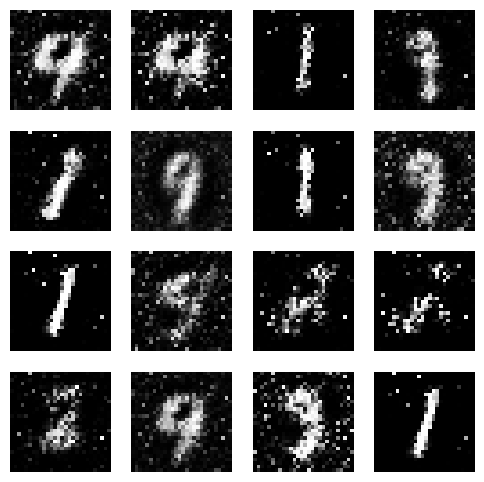

In [10]:
generator.eval()

noise = torch.randn(16, 100).to(device)
fake_images = generator(noise).detach().cpu()

fig, axes = plt.subplots(4,4, figsize=(6,6))
for i, ax in enumerate(axes.flat):
    ax.imshow(fake_images[i][0], cmap='gray')
    ax.axis('off')

plt.show()

Text → Image (Stable Diffusion)

In [16]:
!pip install diffusers transformers accelerate torch --quiet

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/50 [00:00<?, ?it/s]

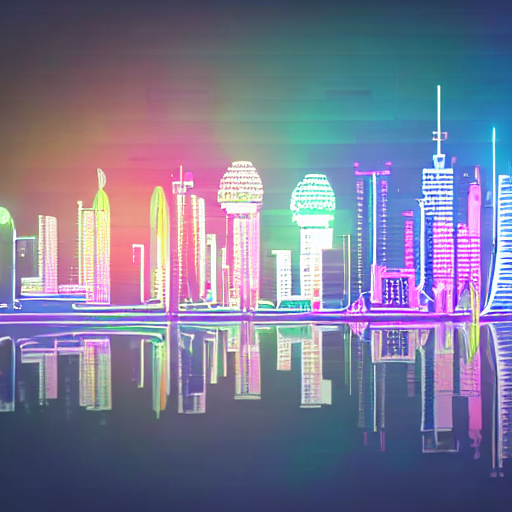

In [17]:
from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

prompt = "A futuristic city floating in the sky with neon lights"

image = pipe(prompt).images[0]
image.save("text_to_image_output.png")

image

Image → Image Translation (Pix2Pix – Pretrained)


In [21]:
!pip install diffusers transformers accelerate torch torchvision --quiet

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/37 [00:00<?, ?it/s]

Image saved at: /kaggle/working/image_to_image_output.png


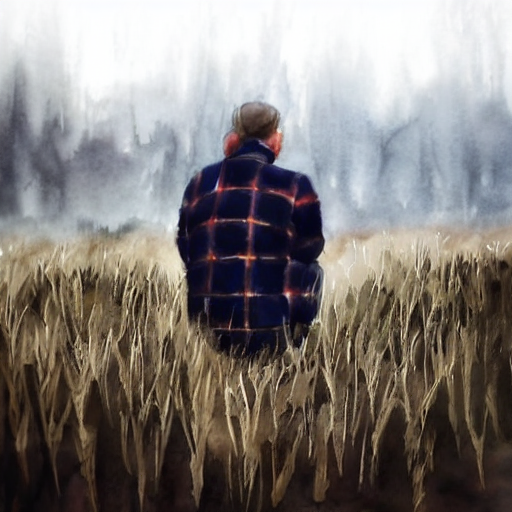

In [24]:
import os
import torch
import requests
from io import BytesIO
from PIL import Image
from diffusers import StableDiffusionImg2ImgPipeline

# Ensure output directory exists
os.makedirs("/kaggle/working", exist_ok=True)

# Load Stable Diffusion Image-to-Image pipeline
pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

# Download sample image
url = "https://images.unsplash.com/photo-1503023345310-bd7c1de61c7d"
response = requests.get(url)

init_image = Image.open(BytesIO(response.content)).convert("RGB")
init_image = init_image.resize((512, 512))

# Define transformation prompt
prompt = "Turn this image into a beautiful watercolor painting"

# Generate new image
result = pipe(
    prompt=prompt,
    image=init_image,
    strength=0.75,
    guidance_scale=7.5
).images[0]

# Save output
output_path = "/kaggle/working/image_to_image_output.png"
result.save(output_path)

print("Image saved at:", output_path)

result

model_index.json:   0%|          | 0.00/485 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--stabilityai--stable-diffusion-x4-upscaler/snapshots/572c99286543a273bfd17fac263db5a77be12c4c/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/75 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion/pipeline_stable_diffusion_upscale.py:528: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


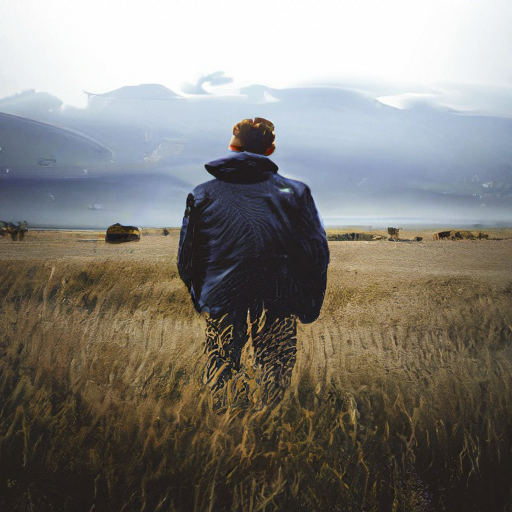

In [25]:
from diffusers import StableDiffusionUpscalePipeline
import requests
from PIL import Image
from io import BytesIO
import torch

pipe_upscale = StableDiffusionUpscalePipeline.from_pretrained(
    "stabilityai/stable-diffusion-x4-upscaler",
    torch_dtype=torch.float16
).to("cuda")

# Download low resolution image
url = "https://images.unsplash.com/photo-1503023345310-bd7c1de61c7d"
response = requests.get(url)
low_res = Image.open(BytesIO(response.content)).convert("RGB")
low_res = low_res.resize((128, 128))  # Make it low resolution

upscaled = pipe_upscale(
    prompt="High resolution detailed image",
    image=low_res
).images[0]

upscaled.save("/kaggle/working/super_resolution_output.png")

upscaled

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/40 [00:00<?, ?it/s]

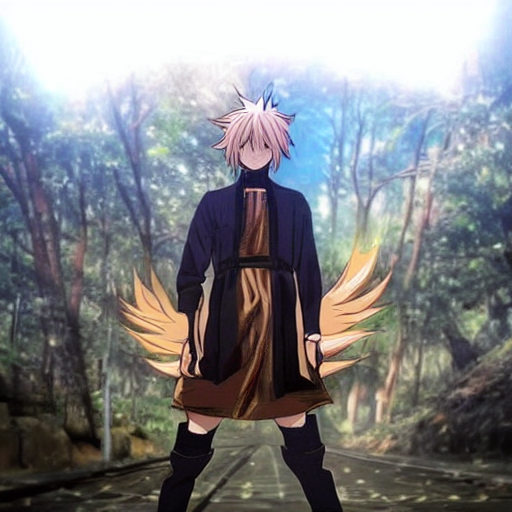

In [28]:
from diffusers import StableDiffusionImg2ImgPipeline
import requests
from PIL import Image
from io import BytesIO
import torch

pipe_domain = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

# Download image
url = "https://images.unsplash.com/photo-1503023345310-bd7c1de61c7d"
response = requests.get(url)
image = Image.open(BytesIO(response.content)).convert("RGB")
image = image.resize((512, 512))

prompt = "Convert this photo into anime style"

output = pipe_domain(
    prompt=prompt,
    image=image,
    strength=0.8
).images[0]

output.save("/kaggle/working/domain_transfer_output.png")

output

In [26]:
!pip install diffusers transformers accelerate torch torchvision --quiet

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/37 [00:00<?, ?it/s]

Image saved at: /kaggle/working/image_to_image_output.png


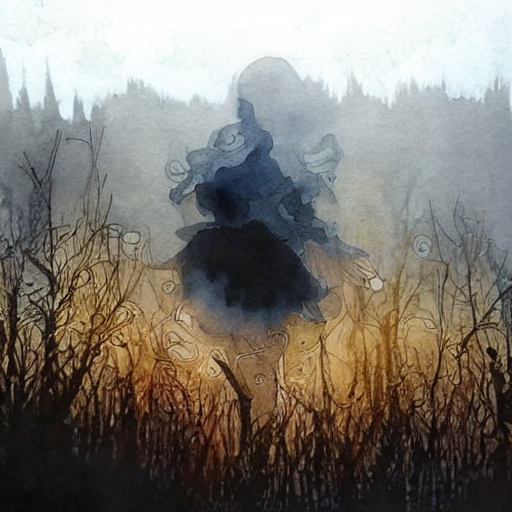

In [27]:
import os
import torch
import requests
from io import BytesIO
from PIL import Image
from diffusers import StableDiffusionImg2ImgPipeline

# Ensure output directory exists
os.makedirs("/kaggle/working", exist_ok=True)

# Load Stable Diffusion Image-to-Image pipeline
pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

# Download sample image
url = "https://images.unsplash.com/photo-1503023345310-bd7c1de61c7d"
response = requests.get(url)

init_image = Image.open(BytesIO(response.content)).convert("RGB")
init_image = init_image.resize((512, 512))

# Define transformation prompt
prompt = "Turn this image into a beautiful watercolor painting"

# Generate new image
result = pipe(
    prompt=prompt,
    image=init_image,
    strength=0.75,
    guidance_scale=7.5
).images[0]

# Save output
output_path = "/kaggle/working/image_to_image_output.png"
result.save(output_path)

print("Image saved at:", output_path)

result

In [34]:
!pip install diffusers transformers accelerate torch torchvision pillow matplotlib --quiet

SGAN / SRGAN (Super-Resolution GAN)
→ Generate High Resolution image from Low Resolution input

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--stabilityai--stable-diffusion-x4-upscaler/snapshots/572c99286543a273bfd17fac263db5a77be12c4c/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/75 [00:00<?, ?it/s]

Saved at: /kaggle/working/super_resolution_output.png


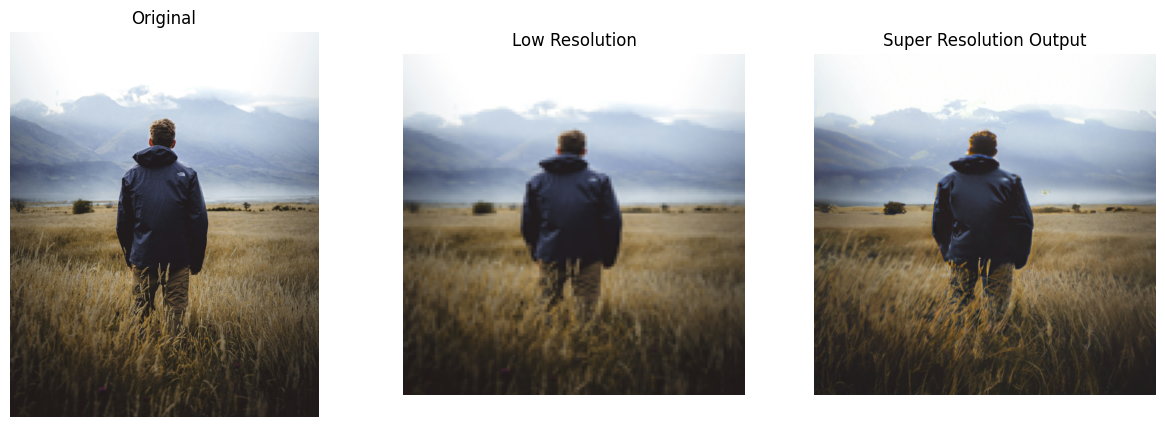

In [35]:
import os
import torch
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
from diffusers import StableDiffusionUpscalePipeline

# Ensure output directory exists
os.makedirs("/kaggle/working", exist_ok=True)

# Select device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load Super Resolution model (x4 upscaler)
pipe = StableDiffusionUpscalePipeline.from_pretrained(
    "stabilityai/stable-diffusion-x4-upscaler",
    torch_dtype=torch.float16
).to(device)

# Download sample image
url = "https://images.unsplash.com/photo-1503023345310-bd7c1de61c7d"
response = requests.get(url)

original = Image.open(BytesIO(response.content)).convert("RGB")

# Create low-resolution version
low_res = original.resize((128, 128))

# Perform super resolution
upscaled = pipe(
    prompt="High resolution detailed photo",
    image=low_res
).images[0]

# Save output
output_path = "/kaggle/working/super_resolution_output.png"
upscaled.save(output_path)

print("Saved at:", output_path)

# Show comparison
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(original)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Low Resolution")
plt.imshow(low_res)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Super Resolution Output")
plt.imshow(upscaled)
plt.axis("off")

plt.show()